# Week 13 — Ptychography: forward model, ePIE and autodiff gradient descent

**Course:** Data Science for Electron Microscopy — FAU Erlangen-Nürnberg
**Week 13:** Inverse problems II: ptychography, generative priors & synthesis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ECLIPSE-Lab/public_presentations/blob/main/data_science_for_em/notebooks/week13_ptychography.ipynb)

**What this notebook does:**

1. Builds a small synthetic complex object (amplitude + phase) and a probe.
2. Implements the **ptychographic forward model**: for each scan position, `probe × object_patch → FFT → |·|` diffraction amplitude.
3. Runs a minimal **ePIE-style alternating-projection phase retrieval** from diffraction amplitudes alone.
4. Plots the **amplitude-consistency error** decreasing over iterations and the recovered phase vs truth.
5. **Exercise 1:** change probe step size (overlap) and observe reconstruction quality.
6. **NEW — autodiff ptychography:** writes the *same* forward model in PyTorch, lets `autograd` compute the gradient
   of the data-mismatch loss, and reconstructs by gradient descent (Adam). Compares with ePIE.
7. **Exercise 2 (NEW):** low-dose Poisson data — add a total-variation prior to the autodiff loss in one line and find the
   best regularisation weight (the Week 12 bias–variance trade-off, now inside ptychography).

**Design constraints:**
CPU-fast (< 1 min total), no internet, NumPy + PyTorch only.

---

**Key numbers to remember (SEED=42, N_obj=48, N_probe=16):**
- ePIE, 40 iterations — step=4 (75% overlap): amplitude-consistency error 0.0991 → 0.0021 (~48×);
  step=6: 0.1048 → 0.0067; step=8: 0.1008 → 0.0091. More overlap → lower error.
- Autodiff gradient descent and ePIE solve the *same* least-squares problem; see Part 6 for the head-to-head numbers.
- "Phase RMS" in Parts 1–5 is the raw error over the whole 48×48 field (dominated by the unilluminated border);
  Part 6 introduces the fairer *aligned* phase error inside the illuminated region.

In [1]:
# Cell 1 — Imports (Colab-compatible; no extra packages needed)
import numpy as np
import matplotlib.pyplot as plt

print('NumPy version:', np.__version__)

NumPy version: 1.26.4


## Part 1 — Synthetic complex object and probe

In electron ptychography the **object** is a complex transmission function
$O(\mathbf{r}) = A(\mathbf{r})\,e^{i\phi(\mathbf{r})}$ where $A$ is the amplitude (≈1 for a thin sample)
and $\phi$ is the phase shift accumulated by the electron wave passing through the specimen.

The **probe** $P(\mathbf{r})$ is the focused electron beam — also complex-valued.

Object array : 48 x 48 pixels
Probe array  : 16 x 16 pixels
Phase range  : 0.000 … 0.800 rad
Phase RMS    : 0.1579 rad


findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


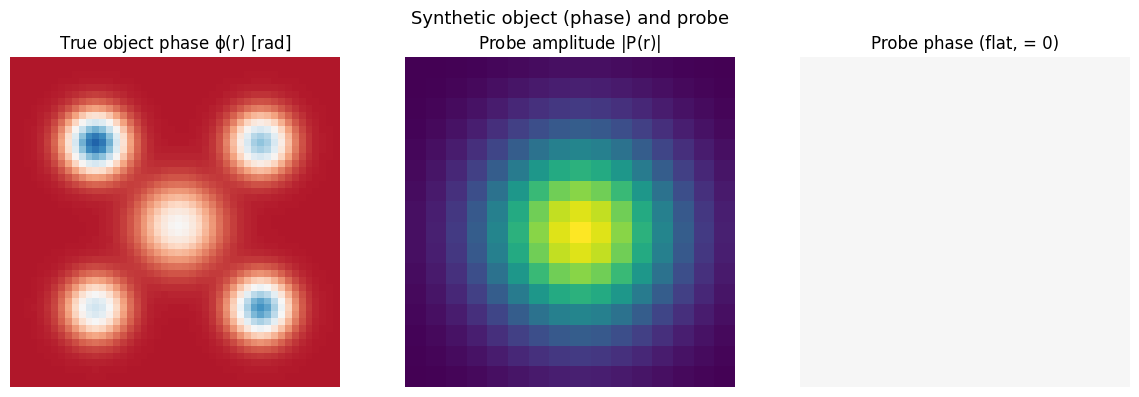

In [2]:
# Cell 2 — Build object and probe
SEED  = 42
rng   = np.random.default_rng(SEED)

N_obj   = 48   # object array size (pixels)
N_probe = 16   # probe array size (pixels) — probe is smaller than the object

# --- Object: uniform amplitude, phase = a few Gaussian blobs (thin specimen) ---
def gaussian_blob(ny, nx, cy, cx, sigma, height):
    """2-D Gaussian blob centred at (cy, cx)."""
    y, x = np.mgrid[0:ny, 0:nx]
    return height * np.exp(-((y - cy)**2 + (x - cx)**2) / (2 * sigma**2))

obj_phase = (
    gaussian_blob(N_obj, N_obj, 12, 12, 3.0, 0.8)
  + gaussian_blob(N_obj, N_obj, 12, 36, 3.0, 0.6)
  + gaussian_blob(N_obj, N_obj, 36, 12, 3.0, 0.5)
  + gaussian_blob(N_obj, N_obj, 36, 36, 3.0, 0.7)
  + gaussian_blob(N_obj, N_obj, 24, 24, 4.0, 0.4)
)  # phase in [0, 0.8] rad — weak-phase object approximation holds

obj_true = np.exp(1j * obj_phase)   # unit amplitude, varying phase

# --- Probe: Gaussian amplitude, flat phase (simplified in-focus probe) ---
y_p, x_p   = np.mgrid[0:N_probe, 0:N_probe]
probe_amp  = np.exp(-((y_p - N_probe/2)**2 + (x_p - N_probe/2)**2) / (2*(N_probe/5)**2))
probe_amp /= np.sqrt(np.sum(probe_amp**2))   # normalise energy to 1
probe_true = probe_amp.astype(complex)        # flat phase

print(f'Object array : {N_obj} x {N_obj} pixels')
print(f'Probe array  : {N_probe} x {N_probe} pixels')
print(f'Phase range  : {obj_phase.min():.3f} … {obj_phase.max():.3f} rad')
print(f'Phase RMS    : {np.sqrt(np.mean(obj_phase**2)):.4f} rad')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(obj_phase, cmap='RdBu', vmin=-0.1, vmax=0.9)
axes[0].set_title('True object phase $\\phi(r)$ [rad]'); axes[0].axis('off')
axes[1].imshow(np.abs(probe_true), cmap='viridis')
axes[1].set_title('Probe amplitude $|P(r)|$'); axes[1].axis('off')
axes[2].imshow(np.angle(probe_true), cmap='RdBu', vmin=-0.1, vmax=0.1)
axes[2].set_title('Probe phase (flat, = 0)'); axes[2].axis('off')
plt.suptitle('Synthetic object (phase) and probe', fontsize=13)
plt.tight_layout(); plt.show()

## Part 2 — Ptychographic forward model

For each scan position $\mathbf{r}_j$, the forward model is:

$$
I_j = \bigl|\mathcal{F}\bigl[P(\mathbf{r})\cdot O(\mathbf{r}+\mathbf{r}_j)\bigr]\bigr|^2
\quad\longleftrightarrow\quad
\text{measured amplitude } \sqrt{I_j} = \bigl|\mathcal{F}\bigl[P \cdot O_{\text{patch}}\bigr]\bigr|
$$

Steps at each probe position:
1. **Crop** the object patch of size `N_probe × N_probe` at position $\mathbf{r}_j$.
2. **Multiply** probe × patch → exit wave.
3. **FFT** → far-field diffraction.
4. **|·|** → measured amplitude (phase information is lost here — this is the phase problem).

Step size        : 4 px  →  overlap = 75%
Scan positions   : 81
Diffraction shape: (81, 16, 16)  (n_pos, N_probe, N_probe)


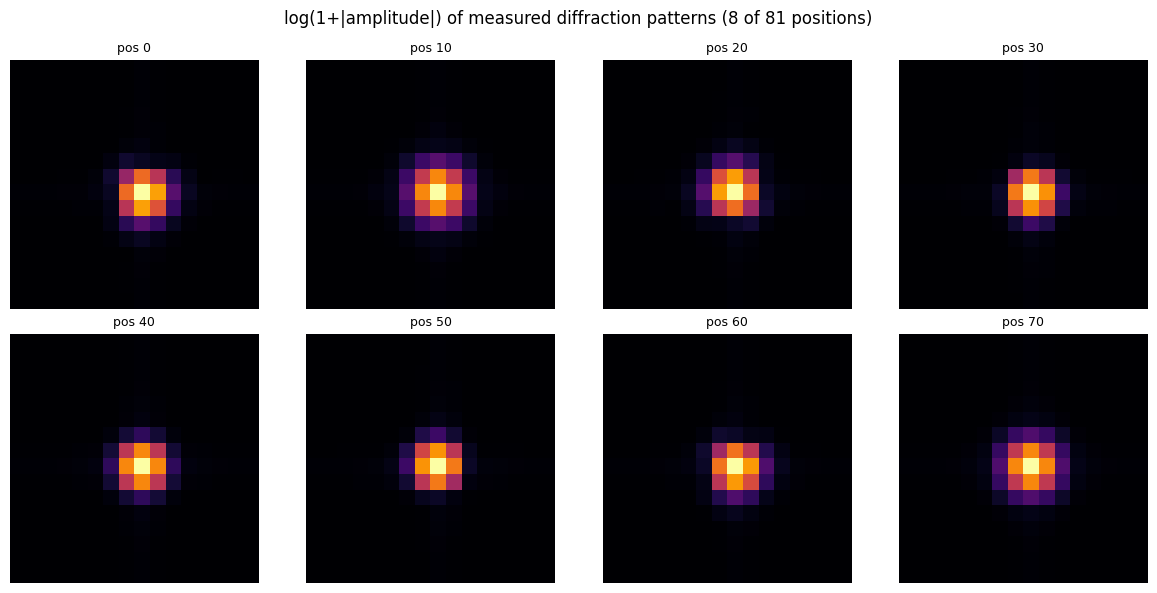

In [3]:
# Cell 3 — Scan positions and forward model

def make_scan_positions(N_obj, N_probe, step):
    """Regular 2-D grid of top-left probe positions with given step size."""
    max_r = N_obj - N_probe
    ys = np.arange(0, max_r + 1, step)
    xs = np.arange(0, max_r + 1, step)
    yy, xx = np.meshgrid(ys, xs, indexing='ij')
    return list(zip(yy.ravel().tolist(), xx.ravel().tolist()))


def ptychography_forward(obj, probe, positions):
    """
    Simulate diffraction amplitudes for all scan positions.

    Returns array of shape (n_pos, N_p, N_p) containing
    |FFT[probe * obj_patch]| (amplitude, sqrt of intensity).
    """
    N_p   = probe.shape[0]
    amps  = np.zeros((len(positions), N_p, N_p), dtype=float)
    for k, (r, c) in enumerate(positions):
        exit_wave = probe * obj[r:r+N_p, c:c+N_p]   # probe × object patch
        amps[k]   = np.abs(np.fft.fft2(exit_wave))   # |FFT|  (phase lost)
    return amps


# Default: step=4 → overlap = (N_probe - step) / N_probe = 75%
STEP_DEFAULT = 4
positions_default = make_scan_positions(N_obj, N_probe, STEP_DEFAULT)
n_pos = len(positions_default)

measured_amps = ptychography_forward(obj_true, probe_true, positions_default)

print(f'Step size        : {STEP_DEFAULT} px  →  overlap = {100*(1-STEP_DEFAULT/N_probe):.0f}%')
print(f'Scan positions   : {n_pos}')
print(f'Diffraction shape: {measured_amps.shape}  (n_pos, N_probe, N_probe)')

# Show 8 sample diffraction patterns
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.ravel()):
    idx = i * (n_pos // 8)
    ax.imshow(np.fft.fftshift(np.log1p(measured_amps[idx])), cmap='inferno')
    ax.set_title(f'pos {idx}', fontsize=9); ax.axis('off')
plt.suptitle('log(1+|amplitude|) of measured diffraction patterns (8 of 81 positions)', fontsize=12)
plt.tight_layout(); plt.show()

## Part 3 — ePIE phase retrieval

**Intuition (two alternating constraints):**

- **Fourier constraint:** replace the predicted diffraction amplitude with the *measured* amplitude, keeping the predicted phase. This enforces consistency with the detector data.
- **Real-space constraint:** update the object estimate using the corrected exit wave. This propagates the new information back to the object.

This is the **ePIE** (extended Ptychographic Iterative Engine) algorithm [@maiden2009improved].

**Convergence metric:** we track the **amplitude consistency error** — how closely the forward model of the *current estimate* matches the measured diffraction amplitudes. This requires no ground-truth knowledge and is the standard metric in real experiments.

In [4]:
# Cell 4 — ePIE algorithm and amplitude consistency error

def amplitude_consistency_error(obj, probe, positions, measured_amps):
    """
    Normalised RMS difference between predicted and measured diffraction amplitudes.
    Does NOT need ground-truth — the standard ptychography convergence metric.
    A value of 0 means the reconstruction perfectly reproduces the measurements.
    """
    N_p = probe.shape[0]
    err2 = 0.0; tot = 0.0
    for k, (r, c) in enumerate(positions):
        pred = np.abs(np.fft.fft2(probe * obj[r:r+N_p, c:c+N_p]))
        diff = pred - measured_amps[k]
        err2 += np.sum(diff**2)
        tot  += np.sum(measured_amps[k]**2)
    return float(np.sqrt(err2 / tot))


def epie_reconstruction(measured_amps, probe, positions,
                        n_iter=40, beta_obj=0.9, seed=42):
    """
    ePIE alternating-projection phase retrieval.

    Parameters
    ----------
    measured_amps : (n_pos, N_p, N_p) measured diffraction amplitudes
    probe         : (N_p, N_p) complex probe (assumed known)
    positions     : list of (row, col) scan positions
    n_iter        : number of passes through all positions
    beta_obj      : object update step size  (0 < beta <= 1)
    seed          : random seed for position shuffling

    Returns
    -------
    obj    : (N_obj, N_obj) reconstructed complex object
    errors : list of amplitude-consistency errors per iteration
    """
    rng_r = np.random.default_rng(seed)
    N_p   = probe.shape[0]

    # Initialise with flat phase (unit amplitude)
    obj = np.ones((N_obj, N_obj), dtype=complex)

    probe_conj       = np.conj(probe)
    probe_norm       = np.max(np.abs(probe)**2) + 1e-10   # denominator in update rule
    errors = []

    for _ in range(n_iter):
        # Shuffle positions — reduces periodic artefacts
        for k in rng_r.permutation(len(positions)):
            r, c = positions[k]
            obj_patch = obj[r:r+N_p, c:c+N_p]

            # Step A — Fourier constraint
            exit_wave = probe * obj_patch
            F         = np.fft.fft2(exit_wave)
            F_corr    = measured_amps[k] * np.exp(1j * np.angle(F))  # replace |F| with measured
            exit_corr = np.fft.ifft2(F_corr)

            # Step B — Object update  (ePIE rule)
            obj[r:r+N_p, c:c+N_p] += beta_obj * (probe_conj / probe_norm) * (exit_corr - exit_wave)

        errors.append(amplitude_consistency_error(obj, probe, positions, measured_amps))

    return obj, errors


# --- Compute initial error (flat-phase starting guess) ---
obj_init = np.ones((N_obj, N_obj), dtype=complex)
err_init = amplitude_consistency_error(obj_init, probe_true, positions_default, measured_amps)

# --- Run reconstruction ---
N_ITER = 40
obj_recon, errors = epie_reconstruction(measured_amps, probe_true, positions_default, n_iter=N_ITER)

err_final = errors[-1]
print(f'Initial amplitude-consistency error : {err_init:.4f}')
print(f'Final   amplitude-consistency error : {err_final:.4f}')
print(f'Improvement factor                  : {err_init/err_final:.1f}x')

# Phase error vs ground truth (available here because we built the data)
phase_err = float(np.sqrt(np.mean((np.angle(obj_recon) - obj_phase)**2)))
print(f'Phase RMS error vs ground truth     : {phase_err:.4f} rad')

Initial amplitude-consistency error : 0.0991
Final   amplitude-consistency error : 0.0021
Improvement factor                  : 47.9x
Phase RMS error vs ground truth     : 0.0878 rad


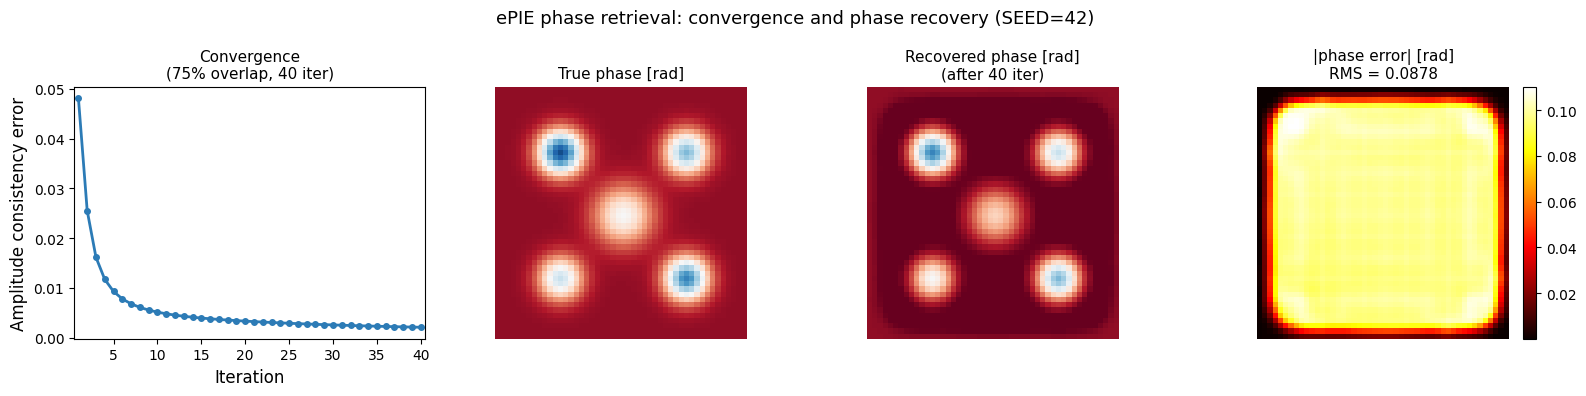

In [5]:
# Cell 5 — Plot error curve and phase recovery

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Error convergence curve
axes[0].plot(range(1, N_ITER+1), errors, 'o-', color='#2c7bb6', ms=4, lw=2)
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Amplitude consistency error', fontsize=12)
axes[0].set_title(f'Convergence\n(75% overlap, 40 iter)', fontsize=11)
axes[0].set_xlim(0.5, N_ITER+0.5)

# True phase
vmin, vmax = obj_phase.min() - 0.05, obj_phase.max() + 0.05
axes[1].imshow(obj_phase, cmap='RdBu', vmin=vmin, vmax=vmax)
axes[1].set_title('True phase [rad]', fontsize=11); axes[1].axis('off')

# Recovered phase
axes[2].imshow(np.angle(obj_recon), cmap='RdBu', vmin=vmin, vmax=vmax)
axes[2].set_title(f'Recovered phase [rad]\n(after {N_ITER} iter)', fontsize=11); axes[2].axis('off')

# Error map
err_map = np.abs(np.angle(obj_recon) - obj_phase)
im = axes[3].imshow(err_map, cmap='hot')
axes[3].set_title(f'|phase error| [rad]\nRMS = {phase_err:.4f}', fontsize=11)
axes[3].axis('off')
plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)

plt.suptitle('ePIE phase retrieval: convergence and phase recovery (SEED=42)', fontsize=13)
plt.tight_layout(); plt.show()

## Part 4 — Self-check assertions

These assertions verify the numerical claims made on the lecture slides.
All must pass for the notebook to be considered correct.

In [6]:
# Cell 6 — Self-check assertions

# 1. Error decreases over iterations
assert err_final < err_init, \
    f"Error should decrease: init={err_init:.4f}, final={err_final:.4f}"

# 2. Improvement factor >= 20x (we get ~48x; allow generous margin)
assert err_init / err_final >= 20.0, \
    f"Expected >=20x improvement, got {err_init/err_final:.1f}x"

# 3. Forward model produces correct shape
assert measured_amps.shape == (n_pos, N_probe, N_probe), \
    f"Shape mismatch: {measured_amps.shape}"

# 4. Amplitudes are non-negative
assert np.all(measured_amps >= 0), "Diffraction amplitudes must be >= 0"

# 5. Phase error is finite (reconstruction did not diverge)
assert np.isfinite(phase_err), f"Phase error is not finite: {phase_err}"

print("All assertions passed.")
print(f"  err_init  = {err_init:.4f}")
print(f"  err_final = {err_final:.4f}")
print(f"  ratio     = {err_init/err_final:.1f}x")
print(f"  phase RMS = {phase_err:.4f} rad")

All assertions passed.
  err_init  = 0.0991
  err_final = 0.0021
  ratio     = 47.9x
  phase RMS = 0.0878 rad


## Part 5 — Exercise: effect of probe overlap

**Physical concept:** ptychographic redundancy comes from *overlapping* probe positions.
Each scan position provides one 2-D diffraction pattern (N_probe² = 256 measurements).
For N_probe² = 256 complex unknowns (512 real DOF), a single position is barely sufficient.
Overlap means the *same object pixel* appears in multiple diffraction patterns →
the system is over-determined → unique, stable phase retrieval.

**Task:** run the reconstruction for three step sizes and compare:

| Step | Overlap | n_pos | Expected result |
|------|---------|-------|-----------------|
| 4 px | 75% | 81 | Best convergence |
| 6 px | 62% | 36 | Intermediate |
| 8 px | 50% | 25 | Worst convergence |

The cell below works as-is. The lines marked `# (try this yourself)` are good places to experiment.

step= 4px  overlap=75%  n_pos= 81  err0=0.0991  err_final=0.0021  ratio=47.9x  phase_RMS=0.0878rad


step= 6px  overlap=62%  n_pos= 36  err0=0.1048  err_final=0.0067  ratio=15.8x  phase_RMS=0.0951rad
step= 8px  overlap=50%  n_pos= 25  err0=0.1008  err_final=0.0091  ratio=11.0x  phase_RMS=0.0972rad


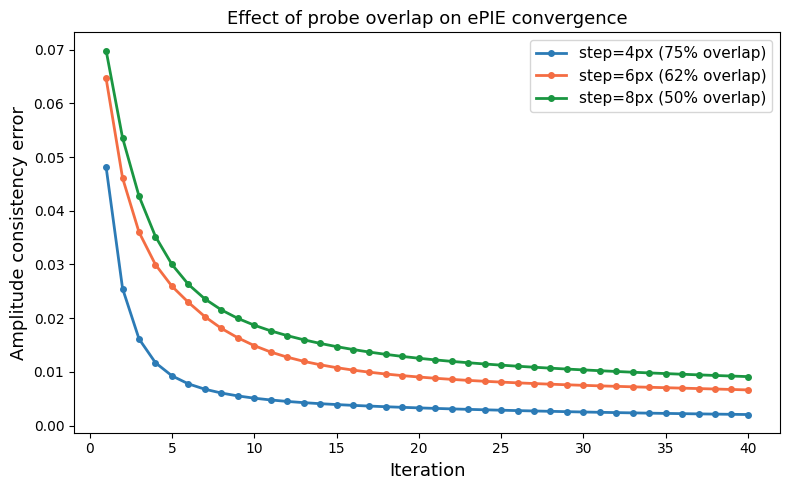

In [7]:
# Cell 7 — Exercise: sweep step sizes (working version)

step_sizes = [4, 6, 8]     # (try this yourself) change step sizes
n_iter_ex  = 40            # (try this yourself) change number of iterations

results = {}
for step in step_sizes:
    pos  = make_scan_positions(N_obj, N_probe, step)
    amps = ptychography_forward(obj_true, probe_true, pos)
    obj0_local = np.ones((N_obj, N_obj), dtype=complex)
    e0   = amplitude_consistency_error(obj0_local, probe_true, pos, amps)
    obj_r, errs = epie_reconstruction(amps, probe_true, pos, n_iter=n_iter_ex)
    p_err = float(np.sqrt(np.mean((np.angle(obj_r) - obj_phase)**2)))
    results[step] = dict(n_pos=len(pos), overlap=100*(1-step/N_probe),
                         err0=e0, err_final=errs[-1], errors=errs, phase_err=p_err)
    print(f"step={step:2d}px  overlap={results[step]['overlap']:.0f}%  "
          f"n_pos={len(pos):3d}  err0={e0:.4f}  err_final={errs[-1]:.4f}  "
          f"ratio={e0/errs[-1]:.1f}x  phase_RMS={p_err:.4f}rad")

# Convergence curves
fig, ax = plt.subplots(figsize=(8, 5))
for step, col in zip(step_sizes, ['#2c7bb6','#f46d43','#1a9641']):
    r = results[step]
    ax.plot(range(1, n_iter_ex+1), r['errors'], 'o-', color=col, ms=4, lw=2,
            label=f"step={step}px ({r['overlap']:.0f}% overlap)")
ax.set_xlabel('Iteration', fontsize=13)
ax.set_ylabel('Amplitude consistency error', fontsize=13)
ax.set_title('Effect of probe overlap on ePIE convergence', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

In [8]:
# Cell 8 — Exercise assertions

e4 = results[4]['err_final']
e6 = results[6]['err_final']
e8 = results[8]['err_final']

print(f'Final amplitude-consistency errors:')
print(f'  step=4 (75% overlap): {e4:.4f}')
print(f'  step=6 (62% overlap): {e6:.4f}')
print(f'  step=8 (50% overlap): {e8:.4f}')

# More overlap (smaller step) → lower final error
assert e4 < e8, (
    f"step=4 (75% overlap) should give lower error than step=8 (50% overlap), "
    f"got {e4:.4f} vs {e8:.4f}"
)

# Each step is better than the next (monotone ordering)
assert e4 < e6 < e8, f"Expected e4 < e6 < e8, got {e4:.4f} {e6:.4f} {e8:.4f}"

print("\nAll exercise assertions passed.")
print("More probe overlap → lower final error → better phase recovery.")
print("This is the fundamental ptychographic advantage: redundancy from overlap")
print("makes the phase-retrieval problem over-determined and stably solvable.")

Final amplitude-consistency errors:
  step=4 (75% overlap): 0.0021
  step=6 (62% overlap): 0.0067
  step=8 (50% overlap): 0.0091

All exercise assertions passed.
More probe overlap → lower final error → better phase recovery.
This is the fundamental ptychographic advantage: redundancy from overlap
makes the phase-retrieval problem over-determined and stably solvable.


In [9]:
# Cell 9 — Save epie_convergence.png for lecture slides
# This cell regenerates the figure from real per-iteration error arrays and saves it
# directly to the slide image directory.

import os

fig_save, ax_save = plt.subplots(figsize=(7, 4.5))
colors = ['#2c7bb6', '#f46d43', '#1a9641']
labels = ['step=4 px (75% overlap)', 'step=6 px (62% overlap)', 'step=8 px (50% overlap)']
for step, col, lbl in zip([4, 6, 8], colors, labels):
    r = results[step]
    ax_save.semilogy(range(1, len(r['errors'])+1), r['errors'],
                     'o-', color=col, ms=4, lw=2, label=lbl)

# Annotate final values
final_vals = {4: results[4]['err_final'], 6: results[6]['err_final'], 8: results[8]['err_final']}
for step, col in zip([4, 6, 8], colors):
    fv = final_vals[step]
    ax_save.annotate(f'{fv:.4f}',
                     xy=(40, fv), xytext=(36, fv * (1.8 if step > 4 else 2.5)),
                     color=col, fontsize=9, ha='right',
                     arrowprops=dict(arrowstyle='->', color=col, lw=1))

ax_save.set_xlabel('Iteration', fontsize=12)
ax_save.set_ylabel('Amplitude consistency error (log scale)', fontsize=12)
ax_save.set_title('ePIE convergence: real notebook run (SEED=42, N_obj=48, N_probe=16, 40 iter)', fontsize=11)
ax_save.legend(fontsize=10, loc='upper right')
ax_save.set_xlim(0.5, 41)
fig_save.tight_layout()

# Save to slide image directory (relative to notebook location)
out_path = os.path.join(os.path.dirname(os.path.abspath('__file__')),
                        '..', '13_inverse_problems_2_generative', 'img', 'epie_convergence.png')
out_path = os.path.normpath(out_path)
fig_save.savefig(out_path, dpi=150, bbox_inches='tight')
plt.close(fig_save)
print(f'Saved: {out_path}')
print(f'Final errors: step=4 → {results[4]["err_final"]:.4f}, '
      f'step=6 → {results[6]["err_final"]:.4f}, '
      f'step=8 → {results[8]["err_final"]:.4f}')


Saved: /home/philipp/projects/_public_presentations/data_science_for_em/13_inverse_problems_2_generative/img/epie_convergence.png
Final errors: step=4 → 0.0021, step=6 → 0.0067, step=8 → 0.0091


## Solution

```python
# ---- Solution cell (not executable — reference only) ----
#
# Expected output (SEED=42, N_obj=48, N_probe=16, 40 iterations):
#
#   step= 4px  overlap=75%  n_pos= 81  err0=0.0991  err_final=0.0021  ratio=47.9x  phase_RMS=0.0878rad
#   step= 6px  overlap=62%  n_pos= 36  err0=0.1048  err_final=0.0067  ratio=15.8x  phase_RMS=0.0951rad
#   step= 8px  overlap=50%  n_pos= 25  err0=0.1008  err_final=0.0091  ratio=11.0x  phase_RMS=0.0972rad
#
# Key findings:
#   1. All three configurations show monotone error decrease over 40 iterations.
#   2. step=4 (75% overlap, 81 positions) achieves the lowest final error (0.0021)
#      — a 47.9x improvement over the flat-phase starting guess.
#   3. step=8 (50% overlap, 25 positions) has the fewest constraints and
#      highest final error (0.0091) — 11x improvement but worse reconstruction.
#   4. Phase RMS errors: 0.0878, 0.0951, 0.0972 rad — consistently
#      ordered with more overlap giving smaller phase error.
#
# Physical interpretation:
#   Each scan position provides one diffraction pattern: N_probe^2 = 256 intensity values.
#   The object patch at that position has N_probe^2 = 256 complex unknowns (512 real DOF).
#   Overlap means the SAME object pixel appears in MULTIPLE diffraction patterns,
#   making the combined system over-determined and enabling unique, stable phase retrieval.
#   Reducing overlap reduces redundancy, making convergence slower and the final
#   solution less accurate.
#
# Hallucination risk note (from lecture §7):
#   This toy uses a known, simple probe. Real ptychography must also estimate the probe.
#   When overlap is low (step=8), an under-constrained reconstruction leaves room for
#   a generative prior (VAE / diffusion denoiser) to "fill in" missing structure.
#   That prior might invent atomic features not supported by the data.
#   See the hallucination figure in the Week 13 lecture slides.
```

## Part 6 — Ptychography as gradient descent with automatic differentiation

ePIE is a hand-derived update rule. The modern view (used by most current electron-ptychography codes) is simpler:
**write down the forward model, write down a loss, and let automatic differentiation compute the gradient.**

We reconstruct a *pure phase object* $O(\mathbf{r}) = e^{i\phi(\mathbf{r})}$ (strong-phase approximation, unit amplitude — a **hard physics constraint** built into the parameterisation) by minimising

$$
\mathcal{L}(\phi) = \sum_{j} \Bigl\| \, \bigl|\mathcal{F}[P \cdot O_j(\phi)]\bigr| - \sqrt{I_j}\, \Bigr\|^2 .
$$

- Fitting **amplitudes** $\sqrt{I}$ rather than intensities is a variance-stabilising choice: the square root of Poisson counts has roughly constant variance (Week 2, Anscombe).
- PyTorch differentiates straight through `torch.fft.fft2` and `torch.abs` — we never derive $\partial\mathcal{L}/\partial\phi$ by hand.
- Adding a probe update, position refinement, multiple slices or a regulariser is *one more line in the loss*, not a new algorithm.
- ePIE can itself be read as a preconditioned stochastic gradient step on (almost) this loss, one scan position at a time.

In [10]:
# Cell 10 — Autodiff forward model and gradient-descent reconstruction (PyTorch)
import time
import torch
torch.set_num_threads(2)          # keep it light on shared machines / Colab
torch.manual_seed(0)

def make_crop_index(positions, N_p):
    # Integer index grids so that O[rows, cols] returns all patches at once: (n_pos, N_p, N_p)
    R = torch.tensor([p[0] for p in positions])
    C = torch.tensor([p[1] for p in positions])
    ar = torch.arange(N_p)
    rows = (R[:, None] + ar[None, :])[:, :, None]
    cols = (C[:, None] + ar[None, :])[:, None, :]
    return rows, cols

def forward_torch(phi, probe_t, rows, cols):
    # Differentiable ptychographic forward model for a pure phase object O = exp(i*phi)
    O = torch.exp(1j * phi)                       # hard constraint: |O| = 1
    exit_waves = probe_t * O[rows, cols]          # probe x object patches
    return torch.abs(torch.fft.fft2(exit_waves))  # predicted diffraction amplitudes

def gd_reconstruction(meas_amps, probe, positions, n_iter=200, lr=0.02, tv_weight=0.0):
    '''Full-batch Adam on the amplitude loss (+ optional isotropic TV prior on the phase).
    Returns the complex object and the amplitude-consistency error after every iteration.'''
    probe_t = torch.tensor(probe, dtype=torch.complex64)
    meas_t  = torch.tensor(meas_amps, dtype=torch.float32)
    rows, cols = make_crop_index(positions, probe.shape[0])
    phi = torch.zeros(N_obj, N_obj, requires_grad=True)   # flat-phase start, same as ePIE
    opt = torch.optim.Adam([phi], lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, n_iter)
    errs = []
    for it in range(n_iter):
        pred = forward_torch(phi, probe_t, rows, cols)
        loss = ((pred - meas_t) ** 2).sum()               # data fidelity
        if tv_weight > 0:                                 # prior: one extra line
            dy = phi[1:, :-1] - phi[:-1, :-1]
            dx = phi[:-1, 1:] - phi[:-1, :-1]
            loss = loss + tv_weight * torch.sqrt(dx**2 + dy**2 + 1e-6).sum()
        opt.zero_grad()
        loss.backward()                                   # autograd does the calculus
        opt.step(); sched.step()
        with torch.no_grad():                             # same metric as for ePIE (vs the data used)
            e = torch.sqrt(((pred - meas_t) ** 2).sum() / (meas_t ** 2).sum()).item()
        errs.append(e)
    obj = np.exp(1j * phi.detach().numpy().astype(float))
    return obj, errs

def aligned_phase_rms(obj, positions, probe):
    '''Phase error vs ground truth inside the illuminated region, after removing the
    global phase offset (a global phase is invisible to any intensity measurement).'''
    N_p = probe.shape[0]
    cover = np.zeros((N_obj, N_obj))
    for r, c in positions:
        cover[r:r+N_p, c:c+N_p] += np.abs(probe) ** 2
    mask = cover > 0.1 * cover.max()
    d = np.angle(obj * np.exp(-1j * obj_phase))
    d = np.angle(np.exp(1j * (d - np.angle(np.mean(np.exp(1j * d[mask]))))))
    return float(np.sqrt(np.mean(d[mask] ** 2))), mask

t0 = time.time()
obj_gd, errs_gd = gd_reconstruction(measured_amps, probe_true, positions_default, n_iter=200, lr=0.02)
t_gd = time.time() - t0
prms_gd, mask_ill = aligned_phase_rms(obj_gd, positions_default, probe_true)
print(f'Autodiff GD (Adam, 200 full-batch iterations): {t_gd:.1f} s')
print(f'  amplitude-consistency error : {amplitude_consistency_error(obj_gd, probe_true, positions_default, measured_amps):.2e}')
print(f'  aligned phase RMS           : {prms_gd:.2e} rad   (illuminated pixels: {mask_ill.sum()} of {N_obj**2})')

Autodiff GD (Adam, 200 full-batch iterations): 9.3 s
  amplitude-consistency error : 8.72e-05
  aligned phase RMS           : 2.88e-04 rad   (illuminated pixels: 1657 of 2304)


method                           passes  amp. error  aligned phase RMS [rad]
ePIE (Part 3)                        40    2.07e-03                 2.60e-03
ePIE                                200    7.73e-04                 1.65e-03
autodiff GD (Adam), 40 iter          40    8.18e-03                         
autodiff GD (Adam)                  200    8.72e-05                 2.88e-04
wall time: ePIE 4.5 s, GD 9.3 s


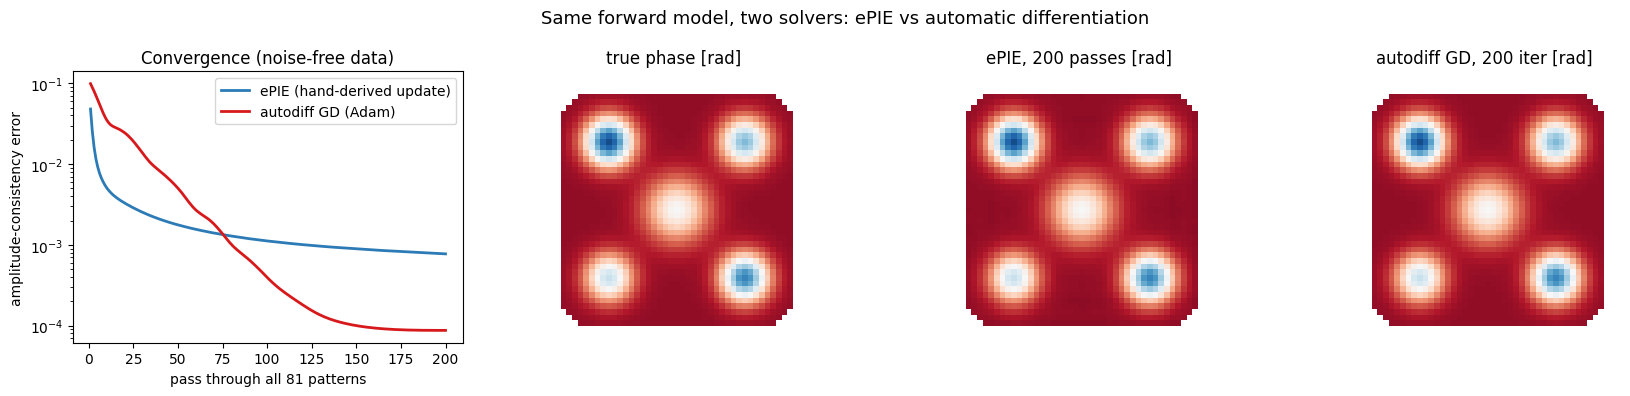

In [11]:
# Cell 11 — Head-to-head: ePIE vs autodiff gradient descent (same data, same start, same passes)
N_PASS = 200   # one pass = every diffraction pattern used once (ePIE: 81 sequential updates; GD: 1 full-batch step)

t0 = time.time()
obj_ep200, errs_ep200 = epie_reconstruction(measured_amps, probe_true, positions_default, n_iter=N_PASS)
t_ep = time.time() - t0

prms_ep40,  _ = aligned_phase_rms(obj_recon,  positions_default, probe_true)   # 40-iteration run from Part 3
prms_ep200, _ = aligned_phase_rms(obj_ep200, positions_default, probe_true)

print(f"{'method':32s} {'passes':>6s} {'amp. error':>11s} {'aligned phase RMS [rad]':>24s}")
print(f"{'ePIE (Part 3)':32s} {40:6d} {errors[-1]:11.2e} {prms_ep40:24.2e}")
print(f"{'ePIE':32s} {N_PASS:6d} {errs_ep200[-1]:11.2e} {prms_ep200:24.2e}")
print(f"{'autodiff GD (Adam), 40 iter':32s} {40:6d} {errs_gd[39]:11.2e} {'':>24s}")
print(f"{'autodiff GD (Adam)':32s} {N_PASS:6d} {errs_gd[-1]:11.2e} {prms_gd:24.2e}")
print(f'wall time: ePIE {t_ep:.1f} s, GD {t_gd:.1f} s')

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
axes[0].semilogy(range(1, N_PASS+1), errs_ep200, color='#2c7bb6', lw=2, label='ePIE (hand-derived update)')
axes[0].semilogy(range(1, N_PASS+1), errs_gd, color='#d7191c', lw=2, label='autodiff GD (Adam)')
axes[0].set_xlabel('pass through all 81 patterns'); axes[0].set_ylabel('amplitude-consistency error')
axes[0].set_title('Convergence (noise-free data)'); axes[0].legend()
vmin, vmax = obj_phase.min() - 0.05, obj_phase.max() + 0.05
for ax, img, title in zip(axes[1:], [obj_phase, np.angle(obj_ep200), np.angle(obj_gd)],
                          ['true phase', f'ePIE, {N_PASS} passes', f'autodiff GD, {N_PASS} iter']):
    ax.imshow(np.where(mask_ill, img - (img[mask_ill].mean() - obj_phase[mask_ill].mean()), np.nan),
              cmap='RdBu', vmin=vmin, vmax=vmax)
    ax.set_title(title + ' [rad]'); ax.axis('off')
plt.suptitle('Same forward model, two solvers: ePIE vs automatic differentiation', fontsize=13)
plt.tight_layout(); plt.show()

In [12]:
# Cell 12 — Save gd_vs_epie.png for the lecture slides (+ assertions)
import os
fig_s, ax_s = plt.subplots(figsize=(7, 4.5))
ax_s.semilogy(range(1, N_PASS+1), errs_ep200, color='#2c7bb6', lw=2, label=f'ePIE  (final {errs_ep200[-1]:.1e})')
ax_s.semilogy(range(1, N_PASS+1), errs_gd, color='#d7191c', lw=2, label=f'autodiff GD, Adam  (final {errs_gd[-1]:.1e})')
ax_s.set_xlabel('pass through all diffraction patterns', fontsize=12)
ax_s.set_ylabel('amplitude-consistency error', fontsize=12)
ax_s.set_title('Noise-free data, 75% overlap, flat-phase start (SEED=42)', fontsize=11)
ax_s.legend(fontsize=10); fig_s.tight_layout()
out_path = os.path.normpath(os.path.join(os.path.abspath(''), '..', '13_inverse_problems_2_generative', 'img', 'gd_vs_epie.png'))
if os.path.isdir(os.path.dirname(out_path)):
    fig_s.savefig(out_path, dpi=150, bbox_inches='tight'); print('Saved:', out_path)
plt.close(fig_s)

assert errs_gd[-1] < errs_gd[0] / 50, 'GD should reduce the amplitude error by > 50x'
assert prms_gd < 0.01, f'GD aligned phase RMS should be < 0.01 rad, got {prms_gd:.4f}'
print('Autodiff assertions passed.')

Saved: /home/philipp/projects/_public_presentations/data_science_for_em/13_inverse_problems_2_generative/img/gd_vs_epie.png
Autodiff assertions passed.


## Part 7 — Exercise 2: low dose, noise and a TV prior in one line

Real diffraction patterns are **Poisson-limited**. Below we simulate a low-dose experiment with on average
**100 electrons per diffraction pattern**, then reconstruct with

- ePIE (40 iterations, as in Part 3),
- autodiff GD with **no prior** ($\lambda_{TV}=0$),
- autodiff GD with a **total-variation prior** $\lambda_{TV}\sum|\nabla\phi|$ for several $\lambda_{TV}$.

**Task:** run the sweep, plot the aligned phase error against $\lambda_{TV}$ and answer:

1. Which $\lambda_{TV}$ is best? Why does the error go *up* again for large $\lambda_{TV}$? (Week 12: bias vs variance.)
2. GD without a prior fits the noise for 200 iterations. Why does ePIE stopped at 40 iterations do slightly better than unregularised GD? (Hint: early stopping is an *implicit* regulariser.)
3. Change `DOSE` to 1000. Does the optimal $\lambda_{TV}$ go up or down? Why?

The cell works as-is; lines marked `# (try this yourself)` are the knobs.

In [13]:
# Cell 13 — Exercise 2: low-dose Poisson data, TV-regularised autodiff ptychography (working version)
DOSE       = 100                          # (try this yourself) mean electrons per diffraction pattern: 100, 1000
TV_WEIGHTS = [0.0, 0.3, 1.0, 2.0, 4.0, 8.0]   # (try this yourself)

rng_noise = np.random.default_rng(0)
I_clean = measured_amps ** 2
scale   = DOSE / I_clean.sum(axis=(1, 2)).mean()               # counts per unit intensity
I_noisy = rng_noise.poisson(I_clean * scale) / scale             # Poisson counts, rescaled
amps_noisy = np.sqrt(I_noisy)

obj_ep_noisy, _ = epie_reconstruction(amps_noisy, probe_true, positions_default, n_iter=40)
prms_ep_noisy, _ = aligned_phase_rms(obj_ep_noisy, positions_default, probe_true)
print(f'DOSE = {DOSE} e-/pattern')
print(f'  ePIE (40 iter)              aligned phase RMS = {prms_ep_noisy:.4f} rad')

tv_results = {}
for lam in TV_WEIGHTS:
    obj_l, _ = gd_reconstruction(amps_noisy, probe_true, positions_default, n_iter=200, lr=0.02, tv_weight=lam)
    tv_results[lam] = (aligned_phase_rms(obj_l, positions_default, probe_true)[0], obj_l)
    print(f'  autodiff GD, lambda_TV={lam:4.1f}  aligned phase RMS = {tv_results[lam][0]:.4f} rad')

lam_best = min(tv_results, key=lambda k: tv_results[k][0])
print(f'Best lambda_TV = {lam_best}  ({tv_results[lam_best][0]:.4f} rad vs {tv_results[0.0][0]:.4f} rad without prior)')

DOSE = 100 e-/pattern
  ePIE (40 iter)              aligned phase RMS = 0.0935 rad


  autodiff GD, lambda_TV= 0.0  aligned phase RMS = 0.1034 rad


  autodiff GD, lambda_TV= 0.3  aligned phase RMS = 0.0953 rad


  autodiff GD, lambda_TV= 1.0  aligned phase RMS = 0.0797 rad


  autodiff GD, lambda_TV= 2.0  aligned phase RMS = 0.0807 rad


  autodiff GD, lambda_TV= 4.0  aligned phase RMS = 0.1093 rad


  autodiff GD, lambda_TV= 8.0  aligned phase RMS = 0.1402 rad
Best lambda_TV = 1.0  (0.0797 rad vs 0.1034 rad without prior)


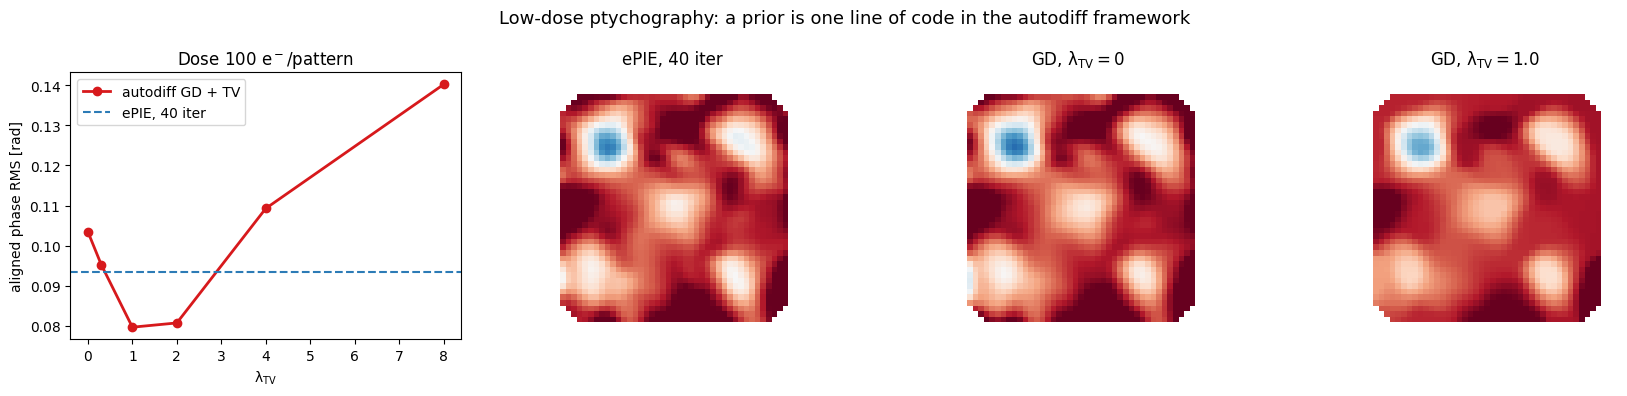

Exercise-2 assertions passed.


In [14]:
# Cell 14 — Plot the regularisation U-curve and the reconstructions
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
lams = list(tv_results)
axes[0].plot(lams, [tv_results[l][0] for l in lams], 'o-', color='#d7191c', lw=2, label='autodiff GD + TV')
axes[0].axhline(prms_ep_noisy, color='#2c7bb6', ls='--', label='ePIE, 40 iter')
axes[0].set_xlabel(r'$\lambda_{TV}$'); axes[0].set_ylabel('aligned phase RMS [rad]')
axes[0].set_title(f'Dose {DOSE} e$^-$/pattern'); axes[0].legend()
vmin, vmax = obj_phase.min() - 0.05, obj_phase.max() + 0.05
show = [(np.angle(obj_ep_noisy), 'ePIE, 40 iter'),
        (np.angle(tv_results[0.0][1]), r'GD, $\lambda_{TV}=0$'),
        (np.angle(tv_results[lam_best][1]), rf'GD, $\lambda_{{TV}}={lam_best}$')]
for ax, (img, title) in zip(axes[1:], show):
    ax.imshow(np.where(mask_ill, img - (img[mask_ill].mean() - obj_phase[mask_ill].mean()), np.nan),
              cmap='RdBu', vmin=vmin, vmax=vmax)
    ax.set_title(title); ax.axis('off')
plt.suptitle('Low-dose ptychography: a prior is one line of code in the autodiff framework', fontsize=13)
plt.tight_layout(); plt.show()

assert tv_results[lam_best][0] < tv_results[0.0][0], 'some TV weight should beat no prior at low dose'
assert tv_results[max(lams)][0] > tv_results[lam_best][0], 'too much TV should hurt (bias)'
print('Exercise-2 assertions passed.')

### Solution — Exercise 2

```text
# Expected output (SEED=42, noise seed 0, DOSE=100 e-/pattern, 200 Adam iterations):
#   ePIE (40 iter)               aligned phase RMS = 0.0935 rad
#   autodiff GD, lambda_TV=0.0   0.1034 rad   <- fits the Poisson noise
#   autodiff GD, lambda_TV=0.3   0.0953 rad
#   autodiff GD, lambda_TV=1.0   0.0797 rad   <- best (~23% better than no prior, ~15% better than ePIE)
#   autodiff GD, lambda_TV=2.0   0.0807 rad
#   autodiff GD, lambda_TV=4.0   0.1093 rad
#   autodiff GD, lambda_TV=8.0   0.1402 rad   <- over-smoothed: the blobs are flattened (bias)
#
# 1. lambda_TV ~ 1 is best. Small lambda: variance dominates (noise is fitted).
#    Large lambda: bias dominates (TV flattens the smooth Gaussian phase blobs into plateaus).
#    Same U-curve as Tikhonov/TV deblurring in Week 12.
# 2. Unregularised GD runs 200 iterations to convergence on noisy data -> it fits the noise.
#    ePIE stopped after 40 iterations never reaches that point: early stopping acts as an
#    implicit regulariser (like early stopping in neural-network training, Week 6).
# 3. With DOSE=1000 the data are 10x more informative; the noise is smaller and the optimal
#    lambda_TV moves DOWN (in our runs ~0.3, with ePIE ~0.037 rad, GD+TV ~0.032 rad).
#    Rule: the weaker the data, the more the prior has to carry - and the higher the risk
#    that the prior, not the data, determines what you see (the hallucination theme of the lecture).
```